# 🏥 Hospital Dataset — Exploratory Data Analysis
## Project: Vision-Based Intelligent Wheelchair Navigation System

**Dataset:** hospital-314ru (Roboflow — HospitalTools workspace)  
**Classes:** Monitor, Saline Stand, bed, bin, chair, sofa, stool, tools_table  
**Total Annotations:** ~2,411  
**Annotation Format:** YOLOv8 (normalised bounding boxes)  

---
### 📋 Notebook Structure
1. Setup & Data Loading
2. Dataset Overview Statistics
3. Class Distribution Analysis
4. Bounding Box Geometry Analysis
5. Spatial Distribution Analysis (Heatmaps)
6. Image Quality Analysis
7. Class Co-occurrence Analysis
8. Dataset Gap Analysis (Navigation Readiness)
9. Sample Visualisation
10. EDA Summary & Recommendations

---
## 📦 SECTION 1 — Setup & Library Installation

**What this does:** Installs and imports all Python libraries we need for the EDA.

- `opencv-python (cv2)` — reads images and draws bounding boxes
- `matplotlib` — creates all our plots and charts
- `seaborn` — makes prettier statistical charts (built on top of matplotlib)
- `numpy` — fast numerical operations on arrays
- `pandas` — stores annotation data in table format for easy analysis
- `glob / os / pathlib` — navigates the folder structure to find all files
- `yaml` — reads the data.yaml config file from Roboflow
- `tqdm` — shows progress bars when processing many files
- `PIL (Pillow)` — alternative image reader, handles edge cases cv2 sometimes misses

In [1]:
# Install missing dependency for YAML parsing (run once)
%pip install pyyaml

# ─── Install dependencies (run once, comment out after) ───────────────────────
# If you are on Colab or a fresh environment, uncomment and run this cell first
# !pip install opencv-python matplotlib seaborn numpy pandas tqdm Pillow pyyaml

# ─── Standard library imports ─────────────────────────────────────────────────
import os
import glob
import yaml
import random
from pathlib import Path
from collections import defaultdict, Counter

# ─── Data science imports ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation imports ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ─── Image processing imports ─────────────────────────────────────────────────
import cv2
from PIL import Image
from tqdm import tqdm

# ─── Global plot styling ──────────────────────────────────────────────────────
# Sets a clean, professional look for all matplotlib charts
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')  # Visually distinct colour palette

print('✅ All libraries imported successfully')
# ─── Helper functions for teammate's visualisations ───────────────────────────
# fig_ok(size): creates a new figure with a clean style
# show_title(t): sets a bold, consistent title on the current axes
def fig_ok(size=(12, 5)):
    """Create a new figure with the project's standard styling."""
    plt.figure(figsize=size)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

def show_title(t):
    """Apply a bold title to the current axes."""
    plt.title(t, fontsize=13, fontweight='bold', pad=12)

print('✅ Helper functions fig_ok() and show_title() defined')


Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully
✅ Helper functions fig_ok() and show_title() defined


---
## 📂 SECTION 2 — Data Loading

**What this does:** Points Python to your dataset folder and reads all the files.

After downloading from Roboflow, your folder structure will look like this:
```
hospital-314ru/
├── data.yaml          ← class names and split paths
├── train/
│   ├── images/        ← .jpg files
│   └── labels/        ← .txt files (one per image)
├── valid/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```

Each `.txt` label file contains one row per object in the format:
`class_id  x_center  y_center  width  height`
All values are normalised to 0–1 relative to image dimensions.

In [2]:
# ─── ⚠️  CHANGE THIS to your actual dataset path ──────────────────────────────
DATASET_ROOT = Path('../Hospital.v1-hospitaldata.yolov8')   # or '/content/hospital-314ru' on Colab

# ─── Read the data.yaml configuration file ────────────────────────────────────
# This gives us the official class names in the correct index order
with open(DATASET_ROOT / 'data.yaml', 'r') as f:
    config = yaml.safe_load(f)

CLASS_NAMES = config['names']   # ['Monitor', 'Saline Stand', 'bed', ...]
NUM_CLASSES = config['nc']      # 8
NUM_TO_NAME = {i: name for i, name in enumerate(CLASS_NAMES)}

print(f'📌 Number of classes: {NUM_CLASSES}')
print(f'📌 Class names: {CLASS_NAMES}')

# ─── Define the colour palette for consistent class colours across all plots ──
PALETTE = sns.color_palette('husl', NUM_CLASSES)
CLASS_COLORS = {name: PALETTE[i] for i, name in enumerate(CLASS_NAMES)}

# ─── Helper function: load all label files from a directory ───────────────────
def load_labels_from_split(split_name):
    """
    Reads all .txt annotation files from a given split (train/valid/test).
    Returns a list of dicts, one per annotation row.
    """
    label_dir = DATASET_ROOT / split_name / 'labels'
    image_dir = DATASET_ROOT / split_name / 'images'
    records = []

    label_files = list(label_dir.glob('*.txt'))

    for label_path in tqdm(label_files, desc=f'Loading {split_name}'):
        img_path = image_dir / (label_path.stem + '.jpg')
        if not img_path.exists():
            img_path = image_dir / (label_path.stem + '.png')

        # Get image dimensions to compute pixel sizes later
        img_w, img_h = 640, 640  # default fallback
        if img_path.exists():
            with Image.open(img_path) as img:
                img_w, img_h = img.size

        with open(label_path, 'r') as f:
            lines = f.read().strip().split('\n')

        if lines == ['']:  # empty label file = image with no annotations
            records.append({
                'split': split_name, 'image': label_path.stem,
                'img_w': img_w, 'img_h': img_h,
                'class_id': None, 'class_name': None,
                'x_center': None, 'y_center': None,
                'bbox_w': None, 'bbox_h': None,
                'bbox_area': None, 'aspect_ratio': None
            })
            continue

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, bw, bh = int(parts[0]), float(parts[1]), \
                                      float(parts[2]), float(parts[3]), float(parts[4])
            records.append({
                'split': split_name,
                'image': label_path.stem,
                'img_w': img_w, 'img_h': img_h,
                'class_id': cls_id,
                'class_name': NUM_TO_NAME.get(cls_id, f'unknown_{cls_id}'),
                'x_center': xc, 'y_center': yc,
                'bbox_w': bw, 'bbox_h': bh,
                'bbox_area': bw * bh,       # normalised area (0–1)
                'aspect_ratio': bw / bh if bh > 0 else 0
            })
    return records

# ─── Load all splits and combine into one master DataFrame ────────────────────
all_records = []
for split in ['train', 'valid', 'test']:
    all_records.extend(load_labels_from_split(split))

df_all = pd.DataFrame(all_records)
df_ann = df_all.dropna(subset=['class_id']).copy()  # annotations only (no empty images)

print(f'\n✅ Total annotation rows loaded: {len(df_ann)}')
print(f'✅ Total images (incl. empty): {df_all["image"].nunique()}')
df_ann.head()
# ─── Alias & extra columns for teammate's visualisations ─────────────────────
# The teammate's code uses shorthand column names: w, h, area, area_px
# We create 'ann' as a renamed view of df_ann so both naming styles work.
ann = df_ann.copy()
ann['w']       = ann['bbox_w']                         # normalised width  (0-1)
ann['h']       = ann['bbox_h']                         # normalised height (0-1)
ann['area']    = ann['bbox_area']                      # normalised area   (0-1)
ann['area_px'] = ann['bbox_w'] * ann['img_w'] * ann['bbox_h'] * ann['img_h']
# area_px: actual pixel area = (norm_w × img_width) × (norm_h × img_height)

print(f'✅ ann DataFrame ready — {len(ann)} rows')
print(f'   Columns added: w, h, area, area_px')
print(f'   area_px range: {ann["area_px"].min():.0f} – {ann["area_px"].max():.0f} px²')


📌 Number of classes: 8
📌 Class names: ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table']


Loading train:   0%|          | 0/1039 [00:00<?, ?it/s]

Loading test: 100%|██████████| 146/146 [00:00<00:00, 603.73it/s]


✅ Total annotation rows loaded: 2411
✅ Total images (incl. empty): 1457
✅ ann DataFrame ready — 2411 rows
   Columns added: w, h, area, area_px
   area_px range: 160 – 6947554 px²


---
## 📊 SECTION 3 — Dataset Overview Statistics

**What this does:** Prints the high-level summary numbers — how many images, how many annotations, and how they are split. This is the very first thing you present in the EDA to orient your audience.

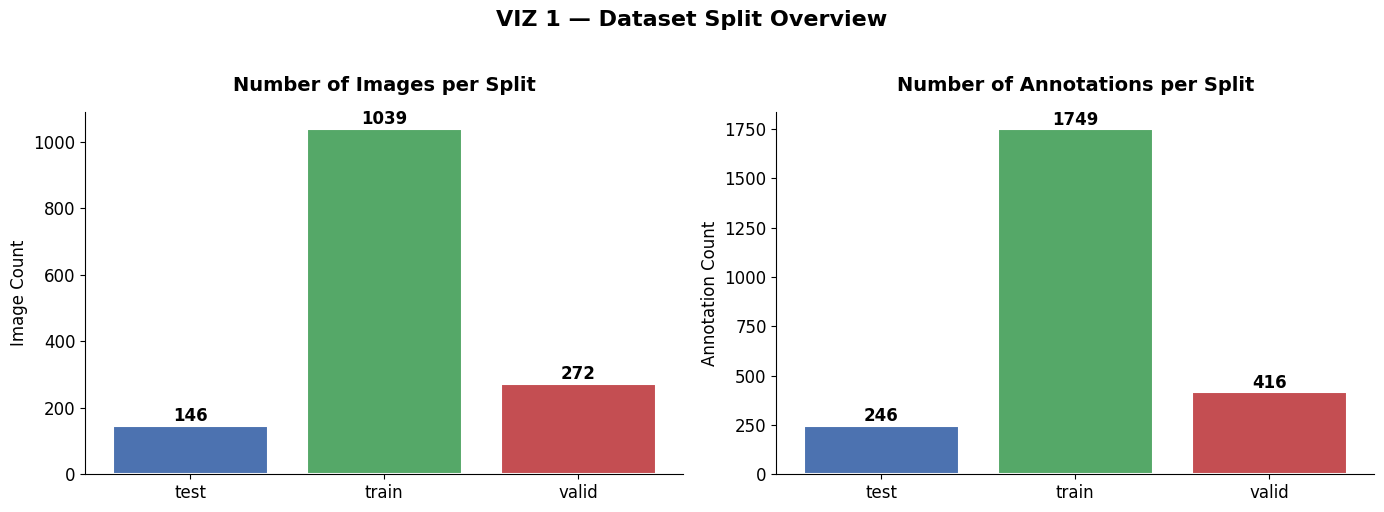


📊 DATASET SUMMARY
Total images:       1457
Total annotations:  2411
Number of classes:  8
Avg annotations/img:1.65
Images with 0 annotations: 0


In [3]:
# ─── VISUALISATION 1: Train / Val / Test Split Bar Chart ─────────────────────
# WHY: Shows whether the dataset split is proportionally reasonable.
# A good split is roughly 70% train, 20% val, 10% test.
# If training data is too small, the model will underfit.

split_img_counts = df_all.groupby('split')['image'].nunique()
split_ann_counts = df_ann.groupby('split').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Images per split
bars = axes[0].bar(split_img_counts.index, split_img_counts.values,
                   color=['#4C72B0','#55A868','#C44E52'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Number of Images per Split', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Image Count')
for bar, val in zip(bars, split_img_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Annotations per split
bars2 = axes[1].bar(split_ann_counts.index, split_ann_counts.values,
                    color=['#4C72B0','#55A868','#C44E52'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Number of Annotations per Split', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Annotation Count')
for bar, val in zip(bars2, split_ann_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')

plt.suptitle('VIZ 1 — Dataset Split Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz01_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print('\n📊 DATASET SUMMARY')
print('='*45)
print(f'Total images:       {df_all["image"].nunique()}')
print(f'Total annotations:  {len(df_ann)}')
print(f'Number of classes:  {NUM_CLASSES}')
print(f'Avg annotations/img:{len(df_ann)/df_all["image"].nunique():.2f}')
empty_imgs = df_all[df_all['class_id'].isna()]['image'].nunique()
print(f'Images with 0 annotations: {empty_imgs}')

---
## 📊 SECTION 4 — Class Distribution Analysis

**Why this matters for navigation:** Class imbalance directly harms model performance.
A model trained on data where `Monitor` (594) is 19× more common than `bin` (31)
will learn to predict monitors well and almost completely ignore bins.
In a hospital corridor, bins are real physical obstacles. Missing them = collision risk.

The known ground truth counts from the metadata are:
Monitor:594, bed:511, sofa:356, tools_table:255, stool:242, Saline Stand:218, chair:204, bin:31

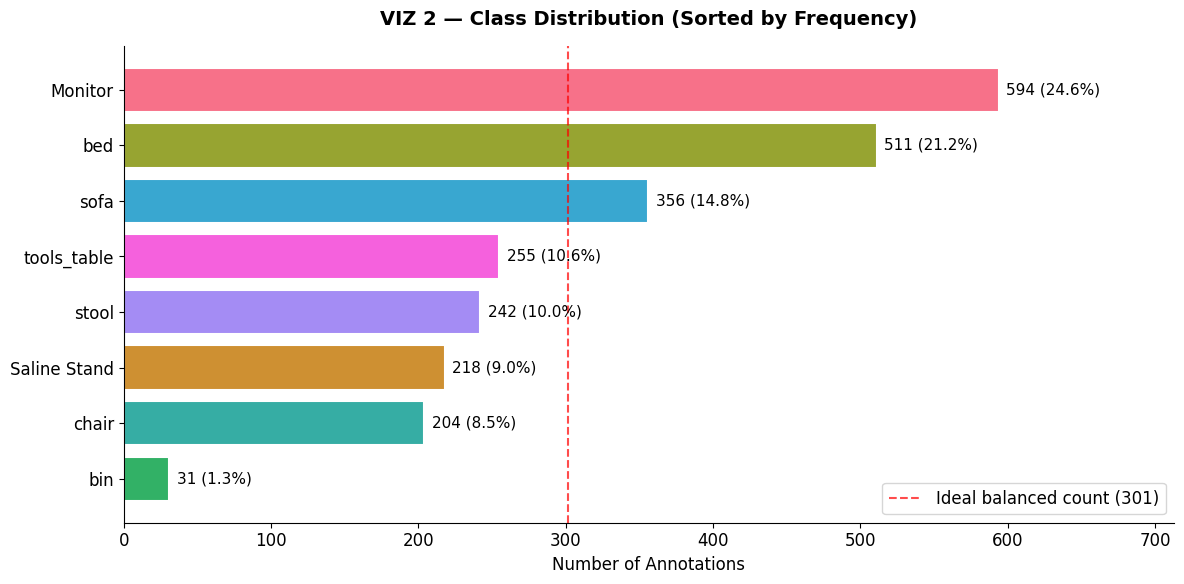

⚠️  Imbalance ratio (max/min): 19.2:1
   Most common:   Monitor (594)
   Least common:  bin (31)


In [4]:
# ─── VISUALISATION 2: Class Distribution Horizontal Bar Chart ────────────────
# WHY: The most important single chart in the EDA. Immediately shows class
# imbalance. Sorted descending so the imbalance gradient is visually obvious.

class_counts = df_ann['class_name'].value_counts().sort_values(ascending=True)
colors = [CLASS_COLORS[c] for c in class_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(class_counts.index, class_counts.values, color=colors,
               edgecolor='white', linewidth=1.5)

# Add value labels at end of each bar
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df_ann)*100:.1f}%)',
            va='center', fontsize=11)

ax.set_xlabel('Number of Annotations', fontsize=12)
ax.set_title('VIZ 2 — Class Distribution (Sorted by Frequency)',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=len(df_ann)/NUM_CLASSES, color='red', linestyle='--',
           alpha=0.7, label=f'Ideal balanced count ({len(df_ann)//NUM_CLASSES})')
ax.legend()
ax.set_xlim(0, class_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('viz02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratio analysis
ratio = class_counts.max() / class_counts.min()
print(f'⚠️  Imbalance ratio (max/min): {ratio:.1f}:1')
print(f'   Most common:   {class_counts.idxmax()} ({class_counts.max()})')
print(f'   Least common:  {class_counts.idxmin()} ({class_counts.min()})')

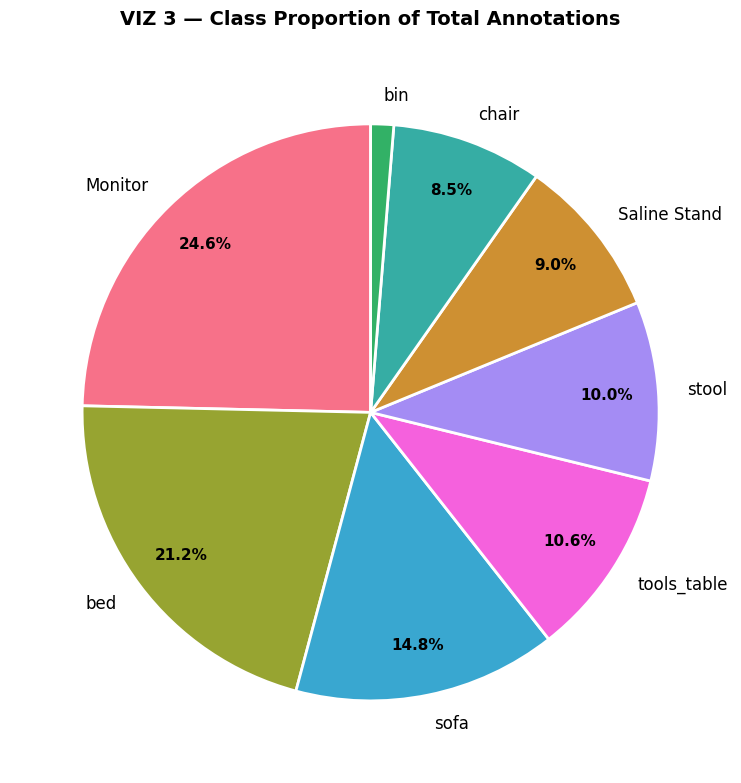

In [5]:
# ─── VISUALISATION 3: Class Distribution Pie Chart ───────────────────────────
# WHY: Pie charts show proportional share better than bar charts.
# When you see that 'bin' is an almost invisible sliver, the imbalance
# becomes viscerally clear — more impactful for presentation audiences.

class_counts_desc = df_ann['class_name'].value_counts()
colors_pie = [CLASS_COLORS[c] for c in class_counts_desc.index]

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    class_counts_desc.values,
    labels=class_counts_desc.index,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',  # hide tiny labels
    colors=colors_pie,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Make percentage labels bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title('VIZ 3 — Class Proportion of Total Annotations',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz03_class_pie.png', dpi=150, bbox_inches='tight')
plt.show()

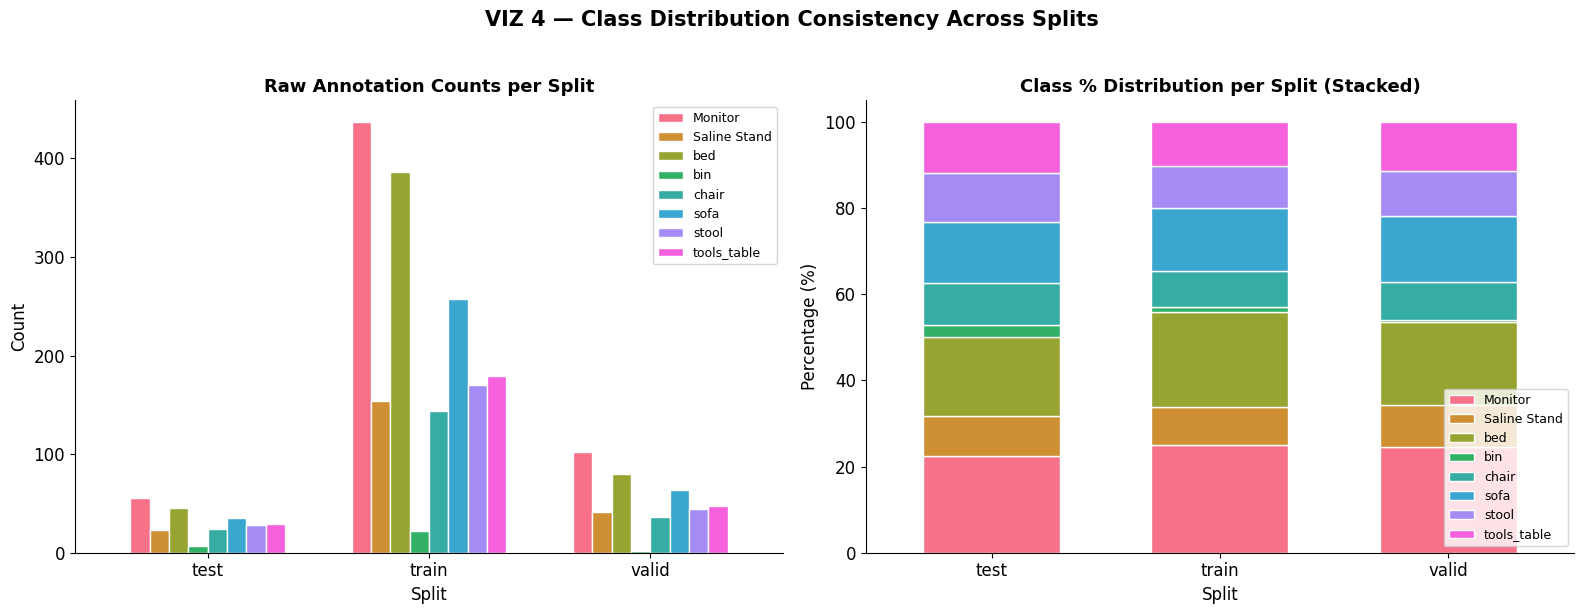

In [6]:
# ─── VISUALISATION 4: Per-Split Class Distribution (Stacked Bar) ──────────────
# WHY: Checks whether classes are CONSISTENTLY distributed across train/val/test.
# If 'bin' only appears in train but not val/test, the model cannot be properly
# evaluated on that class — a critical data quality issue.

split_class = df_ann.groupby(['split','class_name']).size().unstack(fill_value=0)

# Normalise to percentages within each split
split_class_pct = split_class.div(split_class.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
split_class.plot(kind='bar', ax=axes[0], width=0.7,
                 color=[CLASS_COLORS[c] for c in split_class.columns],
                 edgecolor='white')
axes[0].set_title('Raw Annotation Counts per Split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Count')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# Percentage distribution (stacked)
split_class_pct.plot(kind='bar', stacked=True, ax=axes[1], width=0.6,
                     color=[CLASS_COLORS[c] for c in split_class_pct.columns],
                     edgecolor='white')
axes[1].set_title('Class % Distribution per Split (Stacked)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('VIZ 4 — Class Distribution Consistency Across Splits',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz04_split_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📦 SECTION 5 — Annotations Per Image Analysis

**Why this matters:** If most images have only 1-2 objects but some have 20+, the model needs to handle
widely varying scene densities. A hospital corridor during shift change will be very different
from an empty room at night — and the model must handle both.

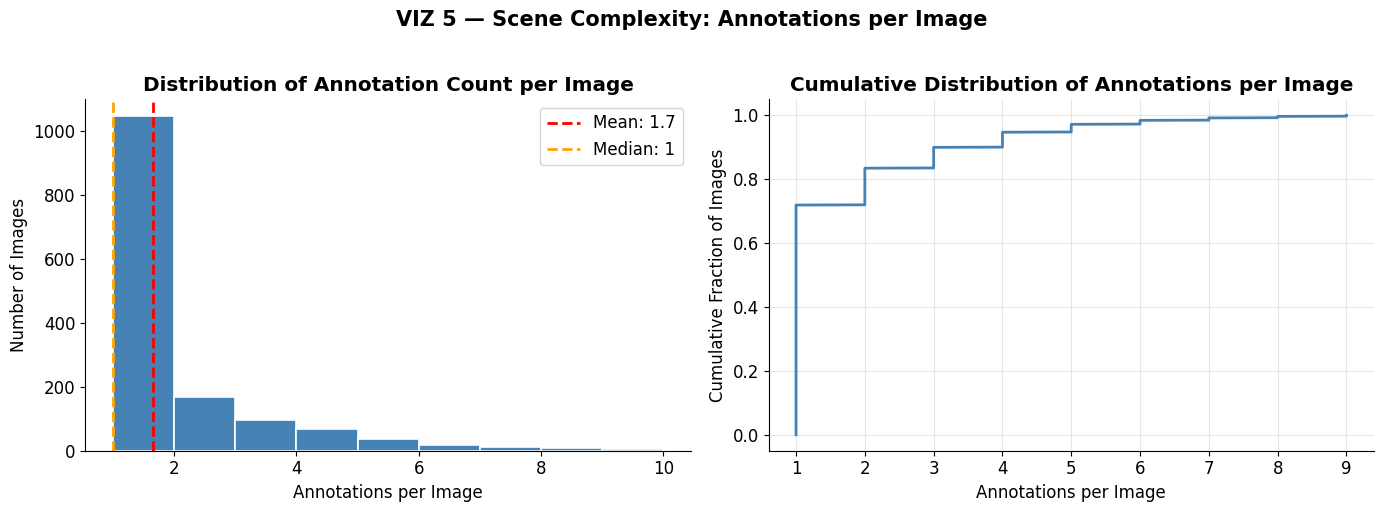

Annotations per image — Mean: 1.65, Median: 1.0, Min: 1, Max: 9


In [7]:
# ─── VISUALISATION 5: Annotations Per Image Histogram ────────────────────────
# WHY: Reveals scene complexity distribution. If the average is very low (e.g. 1-2
# objects per image), the dataset does not represent real hospital crowding.
# For wheelchair navigation, busy scenes with 8-15 objects are the hardest case.

ann_per_image = df_ann.groupby('image').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(ann_per_image.values, bins=range(1, ann_per_image.max()+2),
             color='steelblue', edgecolor='white', linewidth=1.2)
axes[0].axvline(ann_per_image.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {ann_per_image.mean():.1f}')
axes[0].axvline(ann_per_image.median(), color='orange', linestyle='--',
                linewidth=2, label=f'Median: {ann_per_image.median():.0f}')
axes[0].set_xlabel('Annotations per Image')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Distribution of Annotation Count per Image', fontweight='bold')
axes[0].legend()

# Cumulative distribution
sorted_counts = np.sort(ann_per_image.values)
cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, color='steelblue', linewidth=2)
axes[1].set_xlabel('Annotations per Image')
axes[1].set_ylabel('Cumulative Fraction of Images')
axes[1].set_title('Cumulative Distribution of Annotations per Image', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('VIZ 5 — Scene Complexity: Annotations per Image',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz05_annotations_per_image.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Annotations per image — Mean: {ann_per_image.mean():.2f}, '
      f'Median: {ann_per_image.median()}, '
      f'Min: {ann_per_image.min()}, Max: {ann_per_image.max()}')

---
## 📐 SECTION 6 — Bounding Box Geometry Analysis

**Why this matters for YOLOv8:** YOLOv8 (like all YOLO versions) uses anchor-free detection,
meaning it predicts bounding boxes relative to grid cells. The model needs to handle the full
range of object sizes and shapes in your data.

This section uses **histograms** (count-based bars) rather than KDE curves for transparency —
you can see exactly how many bounding boxes fall into each size bucket.

**Columns used:** `ann['w']` = normalised width, `ann['h']` = normalised height,
`ann['area']` = normalised area, `ann['area_px']` = pixel area, `ann['aspect_ratio']` = w/h


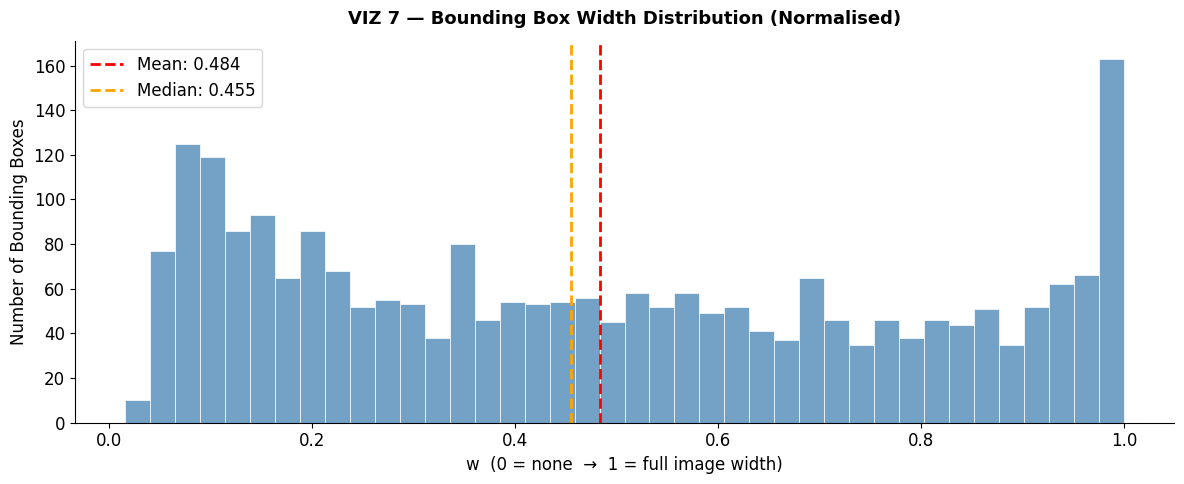

Width — Mean: 0.484  Median: 0.455  Min: 0.016  Max: 1.000


In [8]:
# ─── VISUALISATION 7: Bounding Box Width — Histogram ────────────────────────
# WHY: A histogram (count-based bars) shows exactly how many bounding boxes fall
# into each width bucket — more transparent than a KDE curve.
# We want to see: are most objects narrow (saline stands) or wide (beds, sofas)?
# Peak near 0 = mostly small/narrow objects. Peak near 0.5+ = large, wide objects.
# If the histogram is very flat (no clear peak), width varies widely = camera
# captures objects at many different distances.

fig_ok()
sns.histplot(ann["w"], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
show_title("VIZ 7 — Bounding Box Width Distribution (Normalised)")
plt.xlabel("w  (0 = none  →  1 = full image width)")
plt.ylabel("Number of Bounding Boxes")
plt.axvline(ann['w'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {ann["w"].mean():.3f}')
plt.axvline(ann['w'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {ann["w"].median():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('viz07_bbox_width_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Width — Mean: {ann['w'].mean():.3f}  Median: {ann['w'].median():.3f}"
      f"  Min: {ann['w'].min():.3f}  Max: {ann['w'].max():.3f}")


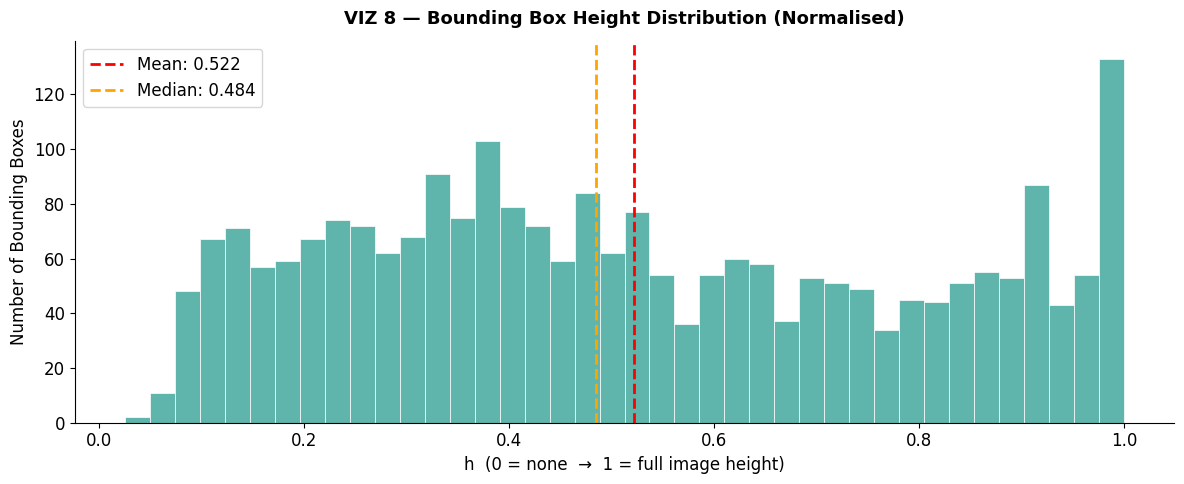

Height — Mean: 0.522  Median: 0.484  Min: 0.025  Max: 1.000


In [9]:
# ─── VISUALISATION 8: Bounding Box Height — Histogram ───────────────────────
# WHY: Height distribution tells us the vertical scale of objects.
# Tall objects (saline stands, people) → peak at higher h values.
# Short objects (bins, tools on a table) → peak at lower h values.
# A wide spread means the camera captures the same object from very
# different distances — the model must handle multi-scale detection.

fig_ok()
sns.histplot(ann["h"], bins=40, color='#2A9D8F', edgecolor='white', linewidth=0.5)
show_title("VIZ 8 — Bounding Box Height Distribution (Normalised)")
plt.xlabel("h  (0 = none  →  1 = full image height)")
plt.ylabel("Number of Bounding Boxes")
plt.axvline(ann['h'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {ann["h"].mean():.3f}')
plt.axvline(ann['h'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {ann["h"].median():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('viz08_bbox_height_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Height — Mean: {ann['h'].mean():.3f}  Median: {ann['h'].median():.3f}"
      f"  Min: {ann['h'].min():.3f}  Max: {ann['h'].max():.3f}")


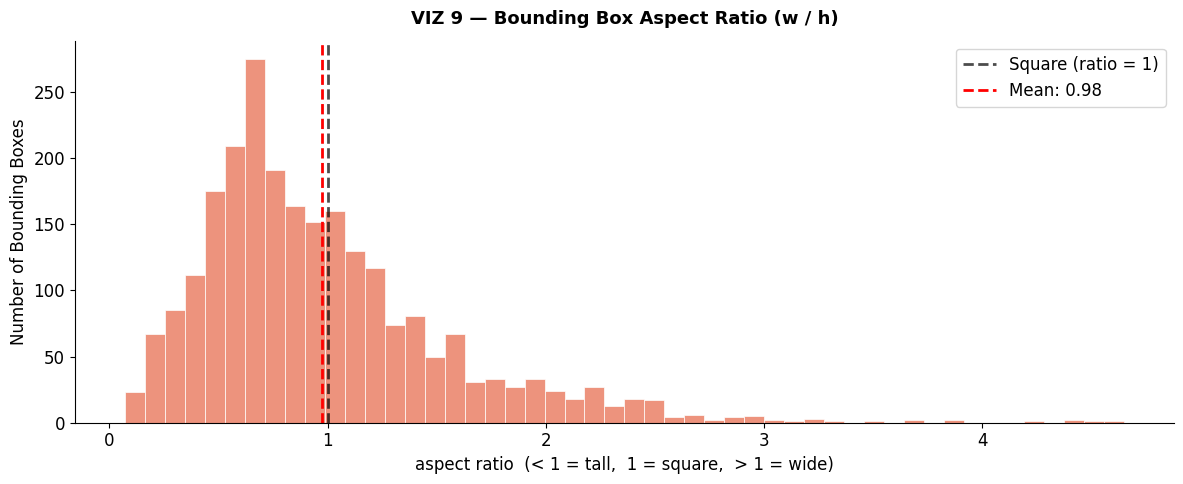

Aspect ratio — Mean: 0.975  Median: 0.841  Skew: 1.616
  Wide objects (ratio > 1): 914 (37.9%)
  Tall objects (ratio < 1): 1484 (61.6%)


In [10]:
# ─── VISUALISATION 9: Bounding Box Aspect Ratio — Histogram ─────────────────
# WHY: Aspect ratio = width / height.
#   ratio > 1  →  wider than tall  (beds, sofas, tools_table)
#   ratio < 1  →  taller than wide (saline stands, bins, monitors on a pole)
#   ratio ≈ 1  →  roughly square   (bins viewed from above, some monitors)
#
# A histogram of ALL classes combined shows the overall shape variety in the
# dataset. Bimodal peaks (two bumps) would reveal two dominant shape families —
# useful for deciding whether to split or merge classes.
# We drop inf values that arise when bbox_h ≈ 0 (corrupted labels).

clean_ar = ann["aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna()

fig_ok()
sns.histplot(clean_ar, bins=50, color='#E76F51', edgecolor='white', linewidth=0.5)
show_title("VIZ 9 — Bounding Box Aspect Ratio (w / h)")
plt.xlabel("aspect ratio  (< 1 = tall,  1 = square,  > 1 = wide)")
plt.ylabel("Number of Bounding Boxes")
plt.axvline(1.0, color='black', linestyle='--', linewidth=2, alpha=0.7,
            label='Square (ratio = 1)')
plt.axvline(clean_ar.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {clean_ar.mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('viz09_aspect_ratio_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Aspect ratio — Mean: {clean_ar.mean():.3f}  Median: {clean_ar.median():.3f}"
      f"  Skew: {clean_ar.skew():.3f}")
print(f"  Wide objects (ratio > 1): {(clean_ar > 1).sum()} ({(clean_ar > 1).mean()*100:.1f}%)")
print(f"  Tall objects (ratio < 1): {(clean_ar < 1).sum()} ({(clean_ar < 1).mean()*100:.1f}%)")


/tmp/ipykernel_7224/3068299765.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ann, x="class_name", y="area", showfliers=False,


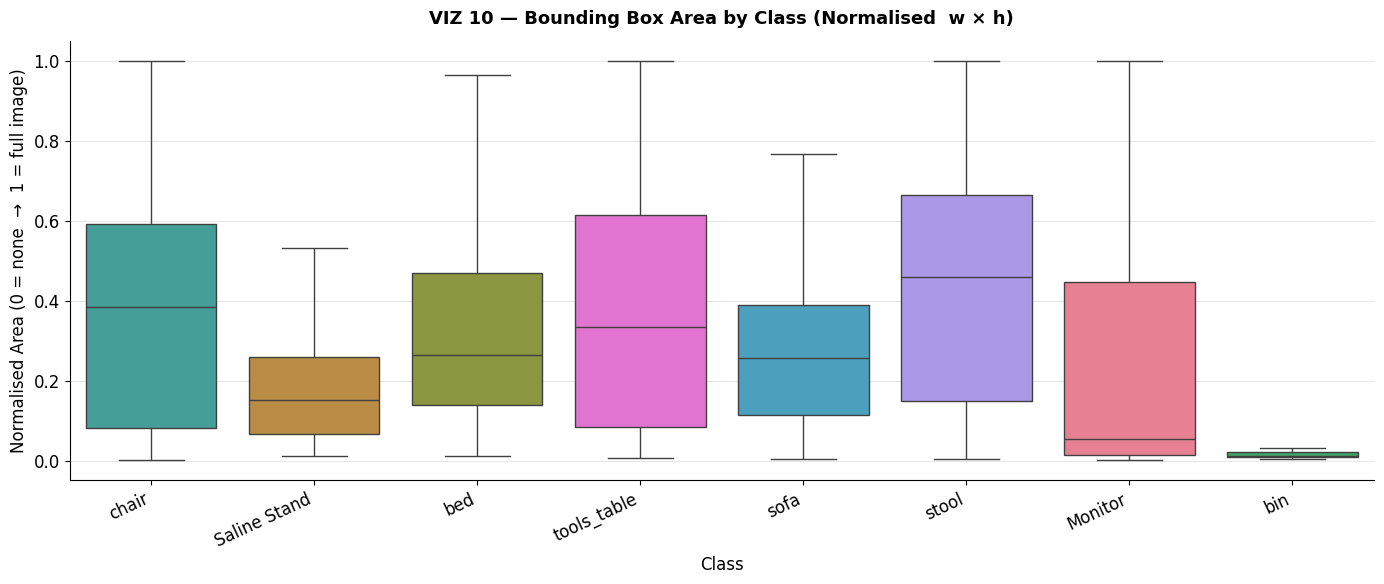

In [11]:
# ─── VISUALISATION 10: Bounding Box Area by Class — Normalised (Seaborn) ──────
# WHY: Area = width × height (normalised 0–1). A seaborn boxplot is cleaner than
# matplotlib's for this comparison because it handles the colour-per-class and
# outlier styling automatically.
# showfliers=False hides extreme outliers so the boxes are readable.
# What to look for:
#   - High median area = physically large objects (bed, sofa)
#   - Low median area  = small or distant objects (bin, stool)
#   - Large IQR box    = camera captures the object at many different distances
#   - Narrow IQR box   = very consistent object size relative to the frame

fig_ok((14, 6))
sns.boxplot(data=ann, x="class_name", y="area", showfliers=False,
            palette=CLASS_COLORS)
plt.xticks(rotation=25, ha="right")
show_title("VIZ 10 — Bounding Box Area by Class (Normalised  w × h)")
plt.ylabel("Normalised Area (0 = none  →  1 = full image)")
plt.xlabel("Class")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz10_area_by_class_norm.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_7224/2580196986.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ann, x='class_name', y='area_px', showfliers=False,


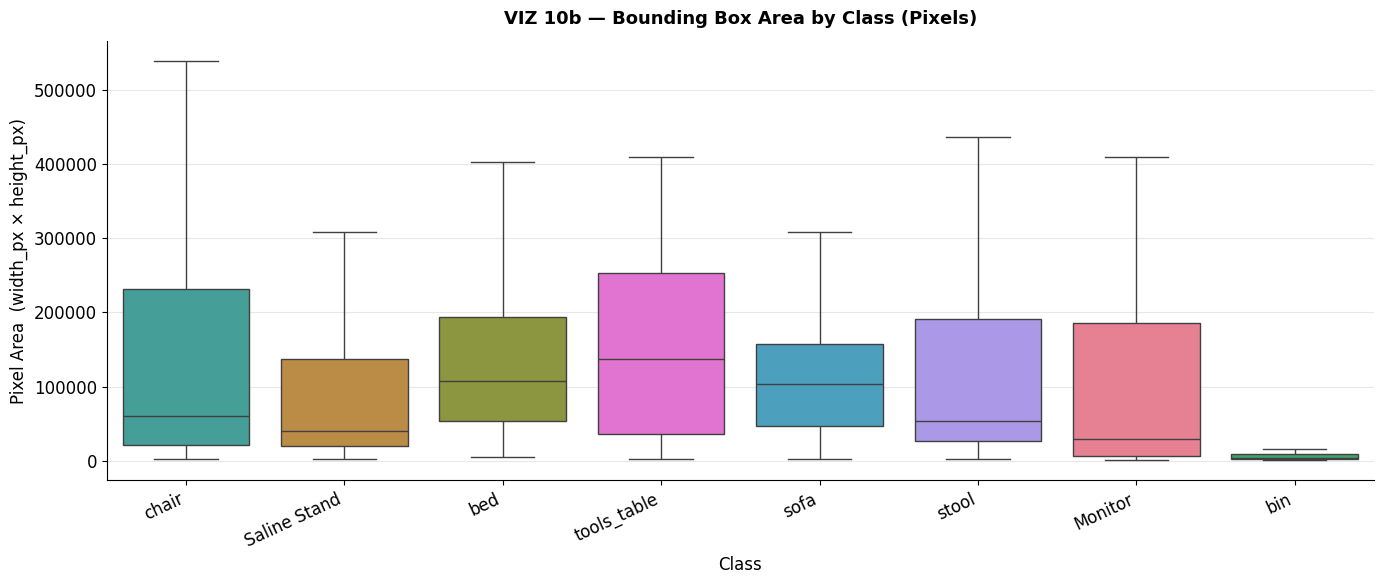


📐 Median pixel area per class (objects < 1024 px² may be hard to detect):
  Monitor                29,220 px²
  Saline Stand           40,027 px²
  bed                   107,702 px²
  bin                     3,502 px²
  chair                  60,214 px²
  sofa                  102,801 px²
  stool                  52,898 px²
  tools_table           136,800 px²


In [12]:
# ─── VISUALISATION 10b: Bounding Box Area by Class — Pixels ─────────────────
# WHY: The normalised area (0–1) tells us relative size, but pixel area tells us
# ABSOLUTE size — how many pixels the object actually covers in the raw image.
# This matters for model performance: YOLOv8 struggles with objects smaller than
# ~32×32 pixels. If the median pixel area of 'bin' is very small, we may need
# to use a higher resolution or tiled inference.
#
# area_px = (bbox_w × img_width) × (bbox_h × img_height)
# e.g. bbox_w=0.1 in a 640px wide image → 64 pixels wide

if len(ann) == 0:
    print('No annotations available for pixel-area plot.')
else:
    fig_ok((14, 6))
    sns.boxplot(data=ann, x='class_name', y='area_px', showfliers=False,
                palette=CLASS_COLORS)
    plt.xticks(rotation=25, ha='right')
    show_title('VIZ 10b — Bounding Box Area by Class (Pixels)')
    plt.ylabel('Pixel Area  (width_px × height_px)')
    plt.xlabel('Class')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('viz10b_area_by_class_pixels.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print minimum median pixel areas to flag small-object detection risk
    print("\n📐 Median pixel area per class (objects < 1024 px² may be hard to detect):")
    for cls in CLASS_NAMES:
        med = ann[ann['class_name'] == cls]['area_px'].median()
        flag = ' ⚠️  SMALL' if med < 1024 else ''
        print(f"  {cls:<18} {med:>10,.0f} px²{flag}")


---
## 🗺️ SECTION 7 — Spatial Distribution Analysis

**Why this matters for navigation:** If objects always appear in the centre of frames,
the model will have a **centre bias** — it performs poorly on objects near the edges.
In a real hospital corridor the camera captures objects to the left, right, and at
varying heights. The following charts use three complementary views:

- **VIZ 11**: `plt.hist2d` — a pixel-grid heatmap counting how many bounding box
  centres fall into each grid cell. Direct, honest, no smoothing.
- **VIZ 12**: Distribution of `x_center` — reveals left/right bias.
- **VIZ 13**: Distribution of `y_center` — reveals top/bottom (near/far) bias.
- **VIZ 14**: Navigable space estimation — unique to this project.


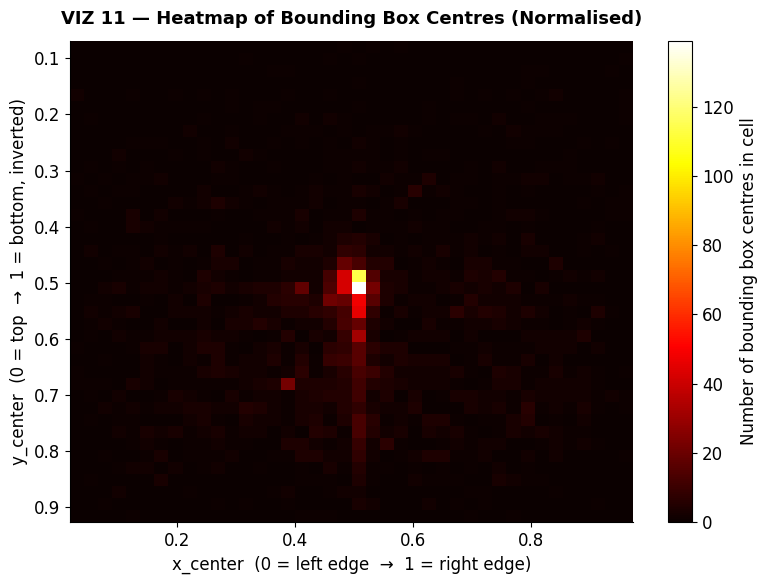

In [13]:
# ─── VISUALISATION 11: Heatmap of Bounding Box Centres (plt.hist2d) ──────────
# WHY: plt.hist2d divides the image into a 40×40 grid and counts how many
# bounding box centres fall into each cell. No smoothing — what you see is
# exactly where annotators placed their labels.
# The colorbar shows the raw count per grid cell.
# y-axis is INVERTED (invert_yaxis) because image coordinates start at the
# top-left: y=0 is the top of the image, y=1 is the bottom.
#
# What to look for:
#   Bright patch in the centre → annotators tended to photograph objects
#   centrally → model will have a centre bias → may miss edge obstacles.
#   Spread across the frame → good spatial diversity → more robust model.

fig_ok((8, 6))
plt.hist2d(ann["x_center"], ann["y_center"], bins=40,
           cmap='hot')
plt.colorbar(label="Number of bounding box centres in cell")
plt.gca().invert_yaxis()   # image y=0 is at the TOP
show_title("VIZ 11 — Heatmap of Bounding Box Centres (Normalised)")
plt.xlabel("x_center  (0 = left edge  →  1 = right edge)")
plt.ylabel("y_center  (0 = top  →  1 = bottom, inverted)")
plt.tight_layout()
plt.savefig('viz11_bbox_centre_hist2d.png', dpi=150, bbox_inches='tight')
plt.show()


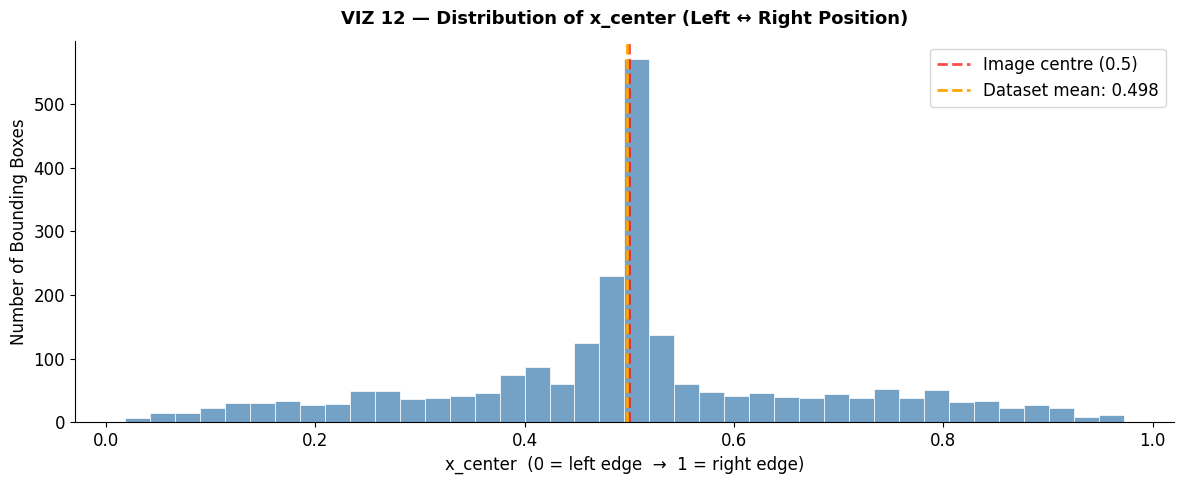

x_center — Mean: 0.498  Std: 0.182
  Objects in left half  (x < 0.5): 50.4%
  Objects in right half (x > 0.5): 45.8%


In [14]:
# ─── VISUALISATION 12: Distribution of x_center ─────────────────────────────
# WHY: x_center tells us whether objects appear more on the LEFT or RIGHT of the
# frame. A perfectly balanced dataset would show a flat uniform distribution
# between 0 and 1.
#
# In hospital corridors:
#   - If x_center peaks at 0.5 (centre) → camera was always pointed straight ahead
#   - If x_center peaks at 0.3 or 0.7 → objects tend to appear on one side
#     (e.g. beds lined up along a corridor wall)
#   - This matters for navigation: the wheelchair needs to detect obstacles on
#     BOTH sides equally well.

fig_ok()
sns.histplot(ann["x_center"], bins=40, color='steelblue',
             edgecolor='white', linewidth=0.5)
show_title("VIZ 12 — Distribution of x_center (Left ↔ Right Position)")
plt.xlabel("x_center  (0 = left edge  →  1 = right edge)")
plt.ylabel("Number of Bounding Boxes")
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label='Image centre (0.5)')
plt.axvline(ann['x_center'].mean(), color='orange', linestyle='--',
            linewidth=2, label=f'Dataset mean: {ann["x_center"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('viz12_x_center_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"x_center — Mean: {ann['x_center'].mean():.3f}  Std: {ann['x_center'].std():.3f}")
left  = (ann['x_center'] < 0.5).mean() * 100
right = (ann['x_center'] > 0.5).mean() * 100
print(f"  Objects in left half  (x < 0.5): {left:.1f}%")
print(f"  Objects in right half (x > 0.5): {right:.1f}%")


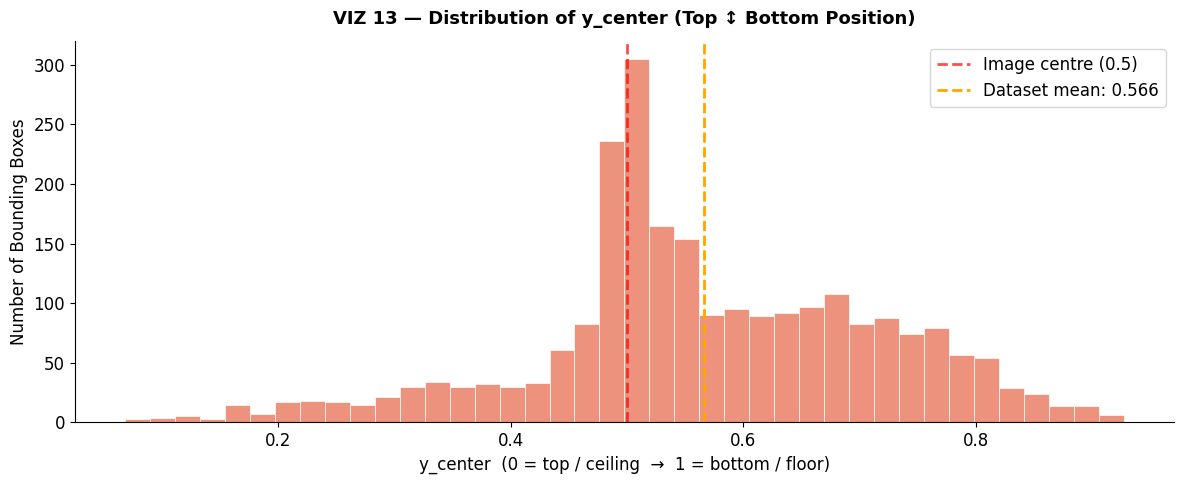

y_center — Mean: 0.566  Std: 0.148
  High objects  (y < 0.4):        10.9%  — ceiling-level
  Mid objects   (0.4 ≤ y ≤ 0.7):  69.1%  — eye-level
  Floor objects (y > 0.7):         20.0%  — floor-level (bins risk zone)


In [15]:
# ─── VISUALISATION 13: Distribution of y_center ─────────────────────────────
# WHY: y_center tells us whether objects appear higher or lower in the frame.
# Remember: in image coordinates y=0 is the TOP of the image (sky / ceiling),
# y=1 is the BOTTOM (floor).
#
# For a wheelchair-mounted camera pointing forward:
#   - y_center near 0.0–0.3 → objects high up (wall-mounted monitors, signs)
#   - y_center near 0.4–0.6 → mid-frame objects (beds, chairs, people)
#   - y_center near 0.7–1.0 → low objects (bins on the floor, wheels)
#
# If low-y objects (bins) cluster near 0.8–1.0 but the model sees few training
# examples there, it will miss bins on the floor — a direct collision risk.

fig_ok()
sns.histplot(ann["y_center"], bins=40, color='#E76F51',
             edgecolor='white', linewidth=0.5)
show_title("VIZ 13 — Distribution of y_center (Top ↕ Bottom Position)")
plt.xlabel("y_center  (0 = top / ceiling  →  1 = bottom / floor)")
plt.ylabel("Number of Bounding Boxes")
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label='Image centre (0.5)')
plt.axvline(ann['y_center'].mean(), color='orange', linestyle='--',
            linewidth=2, label=f'Dataset mean: {ann["y_center"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('viz13_y_center_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"y_center — Mean: {ann['y_center'].mean():.3f}  Std: {ann['y_center'].std():.3f}")
top    = (ann['y_center'] < 0.4).mean() * 100
mid    = ((ann['y_center'] >= 0.4) & (ann['y_center'] <= 0.7)).mean() * 100
bottom = (ann['y_center'] > 0.7).mean() * 100
print(f"  High objects  (y < 0.4):        {top:.1f}%  — ceiling-level")
print(f"  Mid objects   (0.4 ≤ y ≤ 0.7):  {mid:.1f}%  — eye-level")
print(f"  Floor objects (y > 0.7):         {bottom:.1f}%  — floor-level (bins risk zone)")


/tmp/ipykernel_7224/937960769.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  occupancy = df_ann.groupby('image').apply(estimate_occupancy)


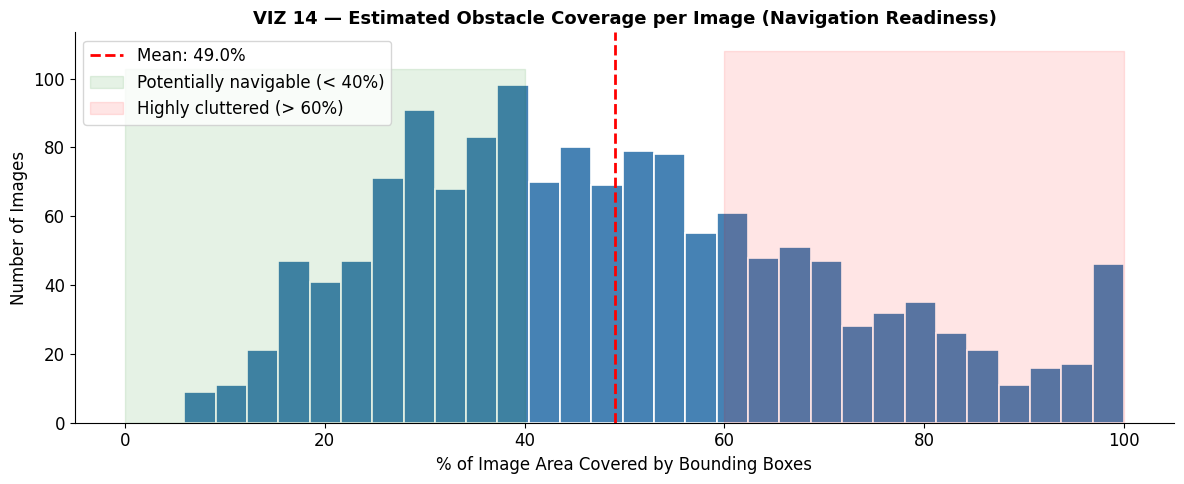

Mean obstacle coverage: 49.0%
Images with > 50% coverage (cluttered): 650 (44.6%)


In [16]:
# ─── VISUALISATION 14: Navigable Space Estimation ────────────────────────────
# WHY: This is unique to your project. For each image, we calculate what fraction
# of the image area is covered by bounding boxes (obstacles) vs uncovered (free).
# For wheelchair navigation: if obstacle coverage is consistently > 60% of the
# frame, the scenes may be too cluttered for confident path planning.
# This directly connects EDA to the navigation research goal.

def estimate_occupancy(group):
    """Estimates non-overlapping occupied area fraction for one image."""
    canvas = np.zeros((100, 100), dtype=np.uint8)
    for _, row in group.iterrows():
        xc, yc, bw, bh = row['x_center'], row['y_center'], row['bbox_w'], row['bbox_h']
        x1 = int(max(0, (xc - bw/2) * 100))
        y1 = int(max(0, (yc - bh/2) * 100))
        x2 = int(min(100, (xc + bw/2) * 100))
        y2 = int(min(100, (yc + bh/2) * 100))
        canvas[y1:y2, x1:x2] = 1
    return canvas.mean()  # fraction of image that is 'occupied'

occupancy = df_ann.groupby('image').apply(estimate_occupancy)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(occupancy.values * 100, bins=30, color='steelblue',
        edgecolor='white', linewidth=1.2)
ax.axvline(occupancy.mean() * 100, color='red', linestyle='--',
           linewidth=2, label=f'Mean: {occupancy.mean()*100:.1f}%')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 50],
                 0, 40, alpha=0.1, color='green', label='Potentially navigable (< 40%)')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 50],
                 60, 100, alpha=0.1, color='red', label='Highly cluttered (> 60%)')
ax.set_xlabel('% of Image Area Covered by Bounding Boxes')
ax.set_ylabel('Number of Images')
ax.set_title('VIZ 14 — Estimated Obstacle Coverage per Image (Navigation Readiness)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz14_navigable_space.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean obstacle coverage: {occupancy.mean()*100:.1f}%')
print(f'Images with > 50% coverage (cluttered): {(occupancy > 0.5).sum()} ({(occupancy > 0.5).mean()*100:.1f}%)')

---
## 🖼️ SECTION 8 — Image Quality Analysis

**Why this matters:** YOLOv8 is sensitive to image quality. Dark, blurry, or low-contrast
images will produce false negatives (missed detections). Hospital CCTV footage often has
poor lighting in corridors, which is exactly the scenario your system will face.

In [17]:
# ─── Image Quality Preprocessing ─────────────────────────────────────────────
# We load a sample of images and compute per-image quality metrics:
#   - mean brightness (average pixel intensity 0-255)
#   - contrast (standard deviation of pixel values — higher = more contrast)
#   - blur score (variance of Laplacian — lower = blurrier)
#   - image dimensions (width × height)

image_quality = []
all_image_paths = []
for split in ['train', 'valid', 'test']:
    img_dir = DATASET_ROOT / split / 'images'
    all_image_paths.extend(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))

# Sample up to 500 images for speed — remove slicing for full analysis
sample_paths = random.sample(all_image_paths, min(500, len(all_image_paths)))

for img_path in tqdm(sample_paths, desc='Analysing image quality'):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    brightness = gray.mean()
    contrast = gray.std()
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    image_quality.append({
        'path': str(img_path),
        'width': w, 'height': h,
        'brightness': brightness,
        'contrast': contrast,
        'blur_score': blur_score
    })

df_quality = pd.DataFrame(image_quality)
print(f'Quality metrics computed for {len(df_quality)} images')
df_quality.describe()

Analysing image quality:   1%|          | 4/500 [00:00<00:13, 38.05it/s]

Analysing image quality: 100%|██████████| 500/500 [00:10<00:00, 47.72it/s]

Quality metrics computed for 500 images


,width,height,brightness,contrast,blur_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,655.508000,657.336000,165.966516,52.170987,551.349001
std,357.704082,309.167644,50.139589,17.187392,606.154933
min,200.000000,200.000000,37.774053,10.411111,2.278896
25%,640.000000,640.000000,124.892567,41.123942,158.055749
50%,640.000000,640.000000,161.620248,51.809455,327.945469
75%,640.000000,640.000000,209.453684,63.931408,757.219008
max,6720.000000,4480.000000,253.903514,109.178033,4294.622837


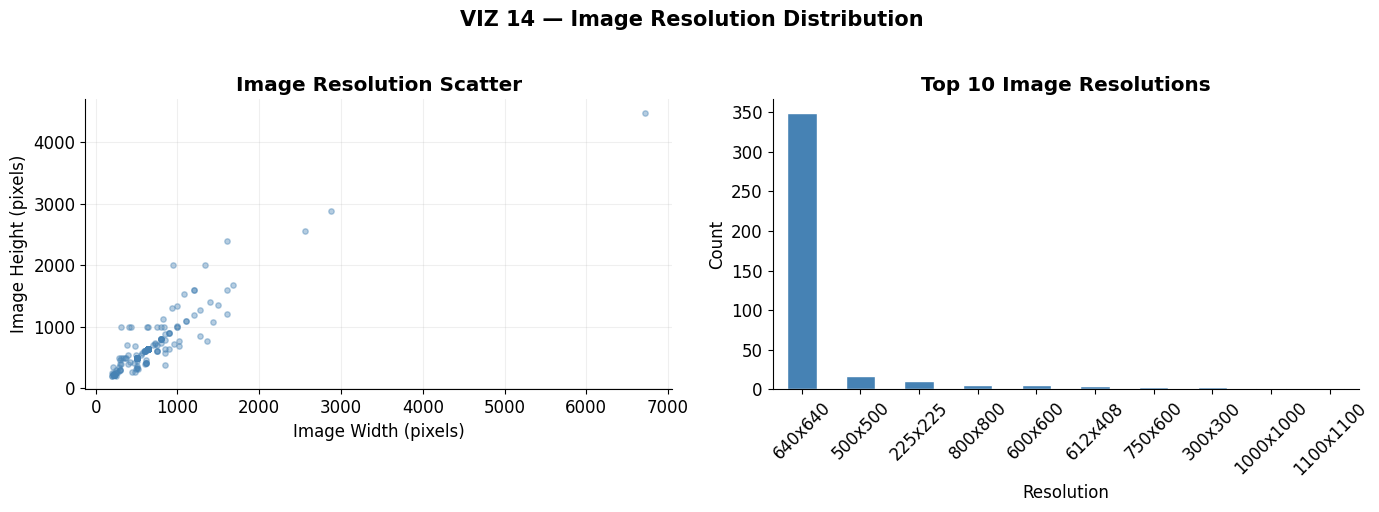

In [18]:
# ─── VISUALISATION 14: Image Resolution Distribution ─────────────────────────
# WHY: If images have mixed resolutions, YOLOv8's default 640×640 input will resize
# some images significantly (distorting aspect ratio) while cropping others.
# You need to know the dominant resolution to set training parameters correctly.
# Outliers (very large or very small images) may cause training instability.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_quality['width'], df_quality['height'],
                alpha=0.4, color='steelblue', s=15)
axes[0].set_xlabel('Image Width (pixels)')
axes[0].set_ylabel('Image Height (pixels)')
axes[0].set_title('Image Resolution Scatter', fontweight='bold')
axes[0].grid(True, alpha=0.2)

# Resolution groups
df_quality['resolution'] = df_quality['width'].astype(str) + 'x' + df_quality['height'].astype(str)
res_counts = df_quality['resolution'].value_counts().head(10)
res_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Image Resolutions', fontweight='bold')
axes[1].set_xlabel('Resolution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('VIZ 14 — Image Resolution Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz14_resolution.png', dpi=150, bbox_inches='tight')
plt.show()

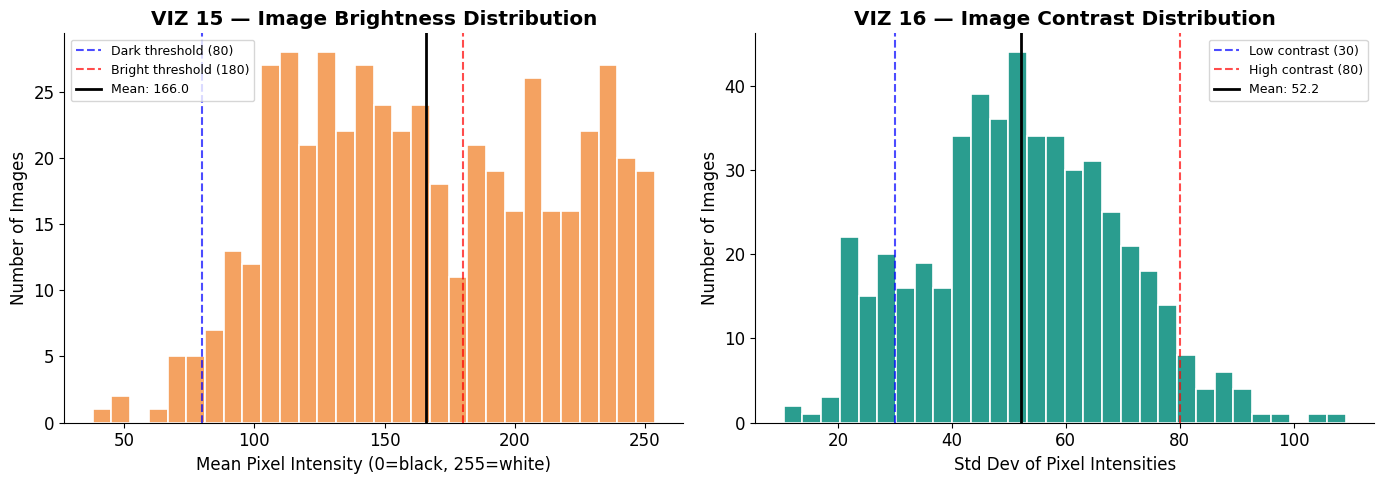

Dark images (brightness < 80): 12 (2.4%)


In [20]:
# ─── VISUALISATION 15: Brightness Distribution ───────────────────────────────
# WHY: Hospital corridors are often poorly lit or have harsh fluorescent lighting.
# The model needs to handle both extremes. If your dataset is all bright images,
# it will fail in dark corridors during night shifts.
# Threshold guide: < 80 = dark, 80-180 = normal, > 180 = overexposed.

# ─── VISUALISATION 16: Contrast Distribution ─────────────────────────────────
# WHY: Low contrast images (std < 30) make it hard to distinguish object boundaries.
# High contrast (std > 80) may indicate harsh shadows from overhead lighting.
# Both extremes should be represented in training data for robust detection.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brightness
axes[0].hist(df_quality['brightness'], bins=30, color='#F4A261',
             edgecolor='white', linewidth=1.2)
axes[0].axvline(80, color='blue', linestyle='--', alpha=0.7, label='Dark threshold (80)')
axes[0].axvline(180, color='red', linestyle='--', alpha=0.7, label='Bright threshold (180)')
axes[0].axvline(df_quality['brightness'].mean(), color='black',
                linewidth=2, label=f'Mean: {df_quality["brightness"].mean():.1f}')
axes[0].set_xlabel('Mean Pixel Intensity (0=black, 255=white)')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('VIZ 15 — Image Brightness Distribution', fontweight='bold')
axes[0].legend(fontsize=9)

# Contrast
axes[1].hist(df_quality['contrast'], bins=30, color='#2A9D8F',
             edgecolor='white', linewidth=1.2)
axes[1].axvline(30, color='blue', linestyle='--', alpha=0.7, label='Low contrast (30)')
axes[1].axvline(80, color='red', linestyle='--', alpha=0.7, label='High contrast (80)')
axes[1].axvline(df_quality['contrast'].mean(), color='black',
                linewidth=2, label=f'Mean: {df_quality["contrast"].mean():.1f}')
axes[1].set_xlabel('Std Dev of Pixel Intensities')
axes[1].set_ylabel('Number of Images')
axes[1].set_title('VIZ 16 — Image Contrast Distribution', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz15_16_brightness_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

dark_imgs = (df_quality['brightness'] < 80).sum()
print(f'Dark images (brightness < 80): {dark_imgs} ({dark_imgs/len(df_quality)*100:.1f}%)')

Computing RGB stats: 100%|██████████| 200/200 [00:02<00:00, 70.49it/s]


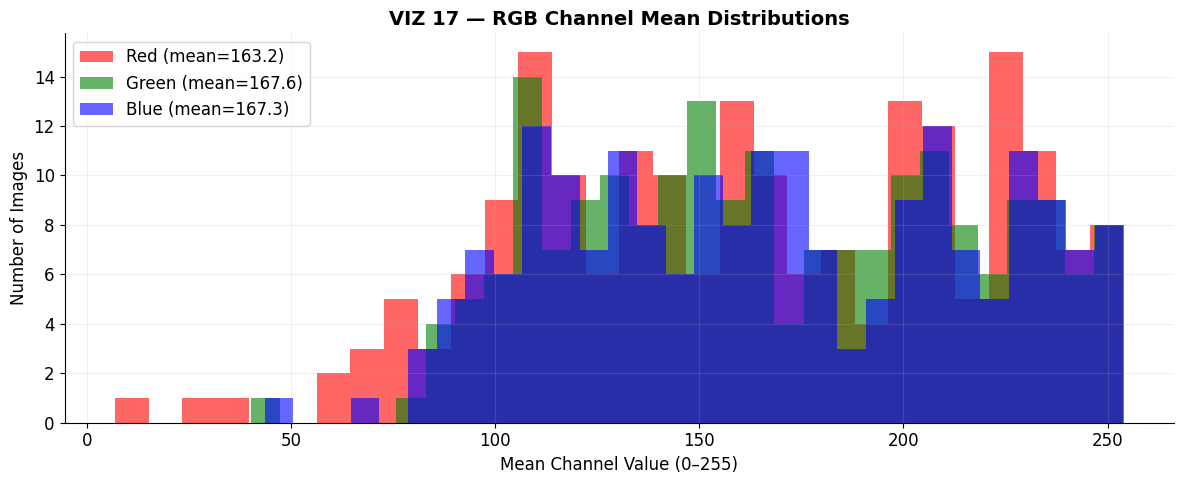

In [21]:
# ─── VISUALISATION 17: RGB Channel Mean Distribution ─────────────────────────
# WHY: Hospital environments have a characteristic cold blue-white colour cast
# from fluorescent lighting. If your dataset's RGB means show this bias, it
# confirms the data is domain-appropriate.
# Also important for normalisation — YOLOv8 by default normalises with
# ImageNet mean=[0.485,0.456,0.406] std=[0.229,0.224,0.225]. If your data
# has a very different colour distribution, custom normalisation may help.

r_means, g_means, b_means = [], [], []

for img_path in tqdm(sample_paths[:200], desc='Computing RGB stats'):
    img = cv2.imread(str(img_path))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r_means.append(img_rgb[:,:,0].mean())
    g_means.append(img_rgb[:,:,1].mean())
    b_means.append(img_rgb[:,:,2].mean())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(r_means, bins=30, alpha=0.6, color='red', label=f'Red (mean={np.mean(r_means):.1f})')
ax.hist(g_means, bins=30, alpha=0.6, color='green', label=f'Green (mean={np.mean(g_means):.1f})')
ax.hist(b_means, bins=30, alpha=0.6, color='blue', label=f'Blue (mean={np.mean(b_means):.1f})')
ax.set_xlabel('Mean Channel Value (0–255)')
ax.set_ylabel('Number of Images')
ax.set_title('VIZ 17 — RGB Channel Mean Distributions',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('viz17_rgb_channels.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔗 SECTION 9 — Class Co-occurrence Analysis

**Why this matters:** Co-occurrence tells us which objects appear together in the same scene.
For navigation: if a bed always appears with a monitor and a saline stand, the model
can learn richer contextual cues. For training: knowing co-occurrence helps design
mosaic augmentation (combining patches from different images into one training image).

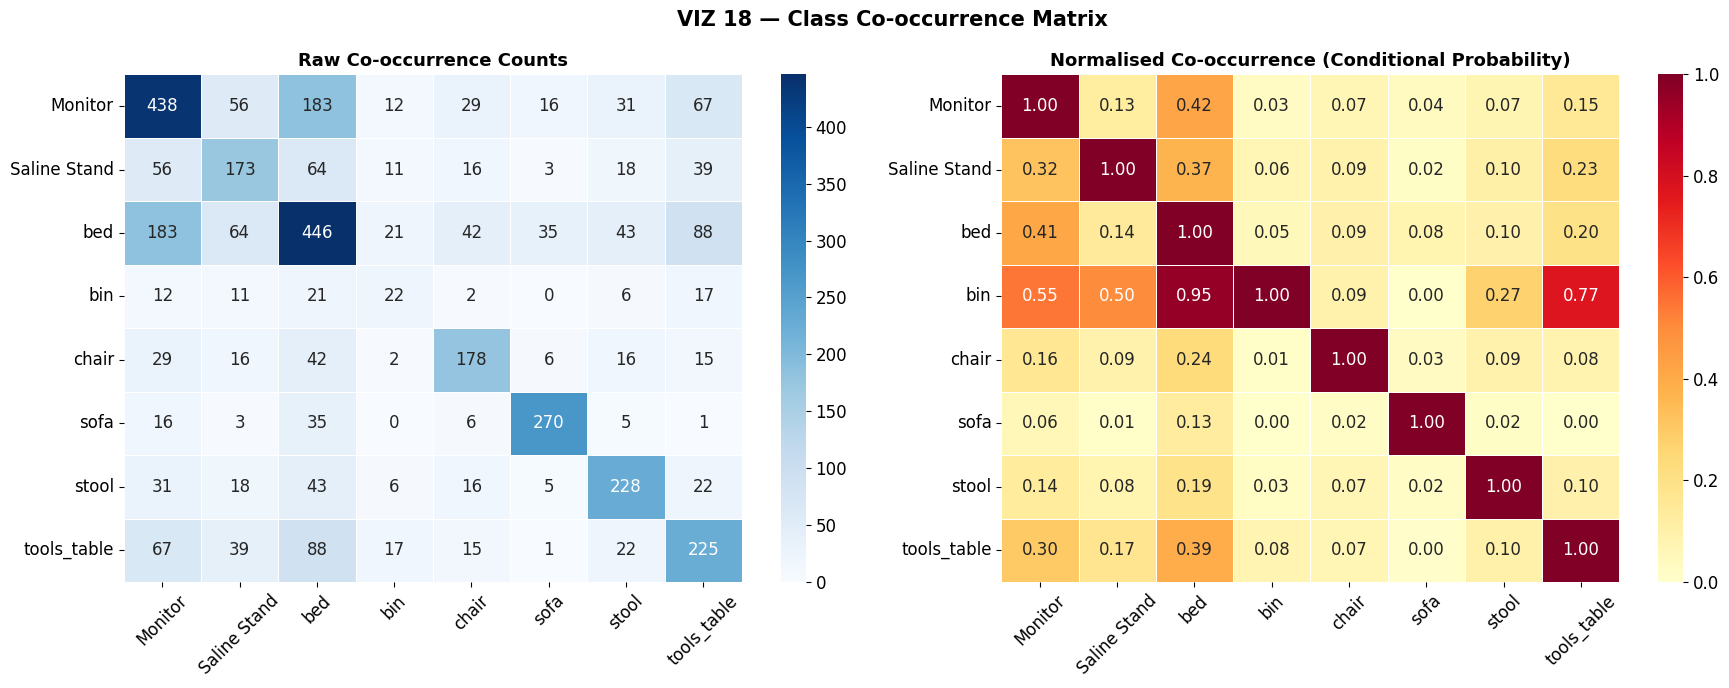

In [22]:
# ─── VISUALISATION 18: Class Co-occurrence Heatmap ───────────────────────────
# WHY: A co-occurrence matrix shows how often class A and class B appear
# in the same image. Dark diagonal = the class always appears with itself (trivial).
# Off-diagonal hot cells = strong co-occurrence pairs.
# Example: if bed+monitor always co-occur, the model learns 'if I see a bed,
# there's probably a monitor nearby' — improving contextual reasoning.

cooccurrence = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

for img_name, group in df_ann.groupby('image'):
    classes_in_image = group['class_id'].unique().astype(int)
    for i in classes_in_image:
        for j in classes_in_image:
            cooccurrence[i][j] += 1

# Normalise by diagonal (self-count) to get conditional probability
cooccurrence_norm = np.zeros_like(cooccurrence, dtype=float)
for i in range(NUM_CLASSES):
    if cooccurrence[i][i] > 0:
        cooccurrence_norm[i] = cooccurrence[i] / cooccurrence[i][i]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Raw Co-occurrence Counts', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalised (conditional probability)
sns.heatmap(cooccurrence_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalised Co-occurrence (Conditional Probability)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('VIZ 18 — Class Co-occurrence Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz18_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🚨 SECTION 10 — Dataset Gap Analysis (Navigation Readiness)

**Why this is the most important analytical section for your research proposal:**
This section directly evaluates whether the dataset is sufficient for the wheelchair
navigation goal. It identifies missing classes, underrepresented scenarios, and
justifies the need for semi-supervised learning or additional data collection.

/tmp/ipykernel_7224/3551010958.py:70: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7224/3551010958.py:71: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('viz19_gap_analysis.png', dpi=150, bbox_inches='tight')
/home/andrew/miniconda3/envs/fantastic-five/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


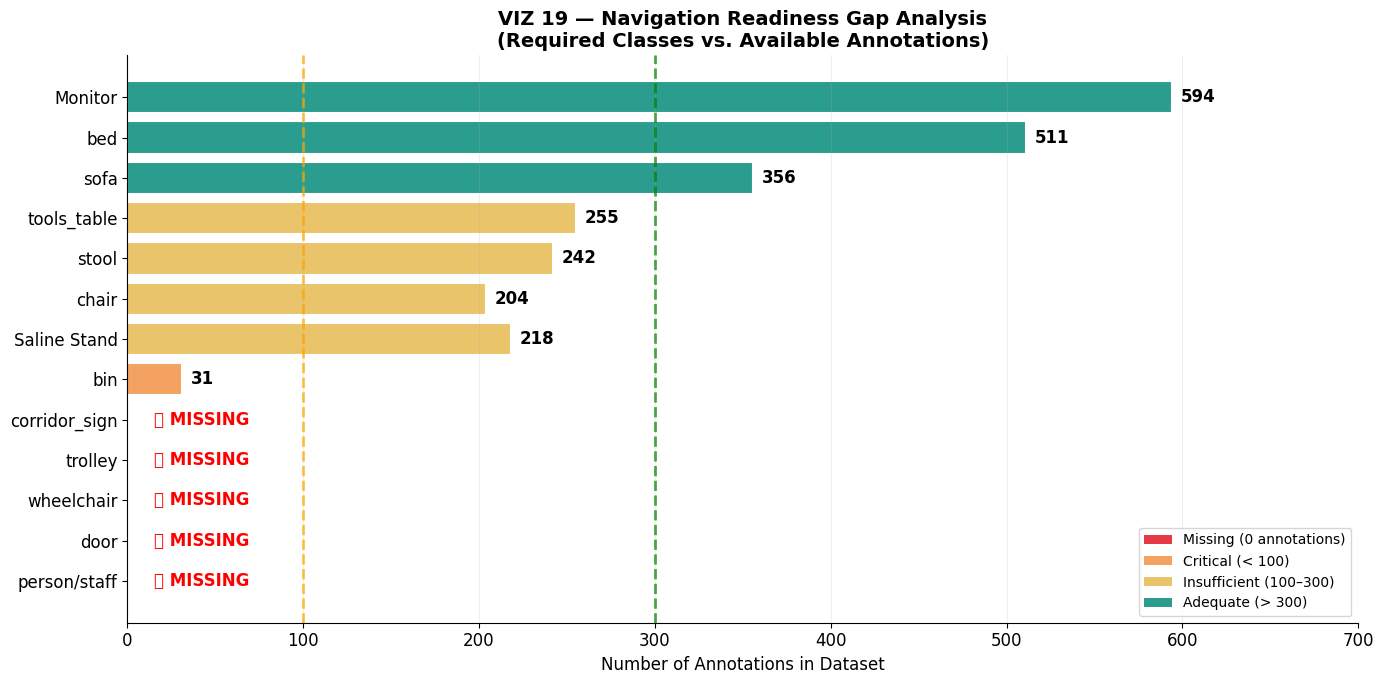

In [23]:
# ─── VISUALISATION 19: Dataset Gap Analysis (Navigation Readiness Chart) ─────
# WHY: This chart is original to YOUR research project. It compares what the
# dataset HAS against what a wheelchair navigation system NEEDS.
# Red bars = completely missing classes. Yellow = present but insufficient.
# Green = adequately represented. This becomes a key slide in your presentation.

# Define what a complete hospital navigation system needs
REQUIRED_CLASSES = {
    'person/staff':     0,    # Not in dataset
    'door':             0,    # Not in dataset
    'wheelchair':       0,    # Not in dataset
    'trolley':          0,    # Not in dataset
    'corridor_sign':    0,    # Not in dataset
    'bin':              31,   # Present but critically low
    'Saline Stand':     218,  # Present but low
    'chair':            204,  # Present but low
    'stool':            242,  # Present
    'tools_table':      255,  # Present
    'sofa':             356,  # Present
    'bed':              511,  # Well represented
    'Monitor':          594,  # Best represented
}

# Threshold for 'adequate' representation (adjust based on literature)
ADEQUATE_THRESHOLD = 300
MINIMUM_THRESHOLD = 100

colors_gap = []
for cls, count in REQUIRED_CLASSES.items():
    if count == 0:
        colors_gap.append('#E63946')  # Red = completely missing
    elif count < MINIMUM_THRESHOLD:
        colors_gap.append('#F4A261')  # Orange = critically low
    elif count < ADEQUATE_THRESHOLD:
        colors_gap.append('#E9C46A')  # Yellow = present but insufficient
    else:
        colors_gap.append('#2A9D8F')  # Green = adequate

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = range(len(REQUIRED_CLASSES))
bars = ax.barh(list(REQUIRED_CLASSES.keys()), list(REQUIRED_CLASSES.values()),
               color=colors_gap, edgecolor='white', linewidth=1.5)

ax.axvline(ADEQUATE_THRESHOLD, color='green', linestyle='--',
           linewidth=2, alpha=0.7, label=f'Adequate threshold ({ADEQUATE_THRESHOLD})')
ax.axvline(MINIMUM_THRESHOLD, color='orange', linestyle='--',
           linewidth=2, alpha=0.7, label=f'Minimum threshold ({MINIMUM_THRESHOLD})')

for bar, val in zip(bars, REQUIRED_CLASSES.values()):
    label = str(val) if val > 0 else '❌ MISSING'
    ax.text(max(val + 5, 15), bar.get_y() + bar.get_height()/2,
            label, va='center', fontweight='bold',
            color='red' if val == 0 else 'black')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E63946', label='Missing (0 annotations)'),
    Patch(facecolor='#F4A261', label='Critical (< 100)'),
    Patch(facecolor='#E9C46A', label='Insufficient (100–300)'),
    Patch(facecolor='#2A9D8F', label='Adequate (> 300)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_xlabel('Number of Annotations in Dataset')
ax.set_title('VIZ 19 — Navigation Readiness Gap Analysis\n'
             '(Required Classes vs. Available Annotations)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 700)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('viz19_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

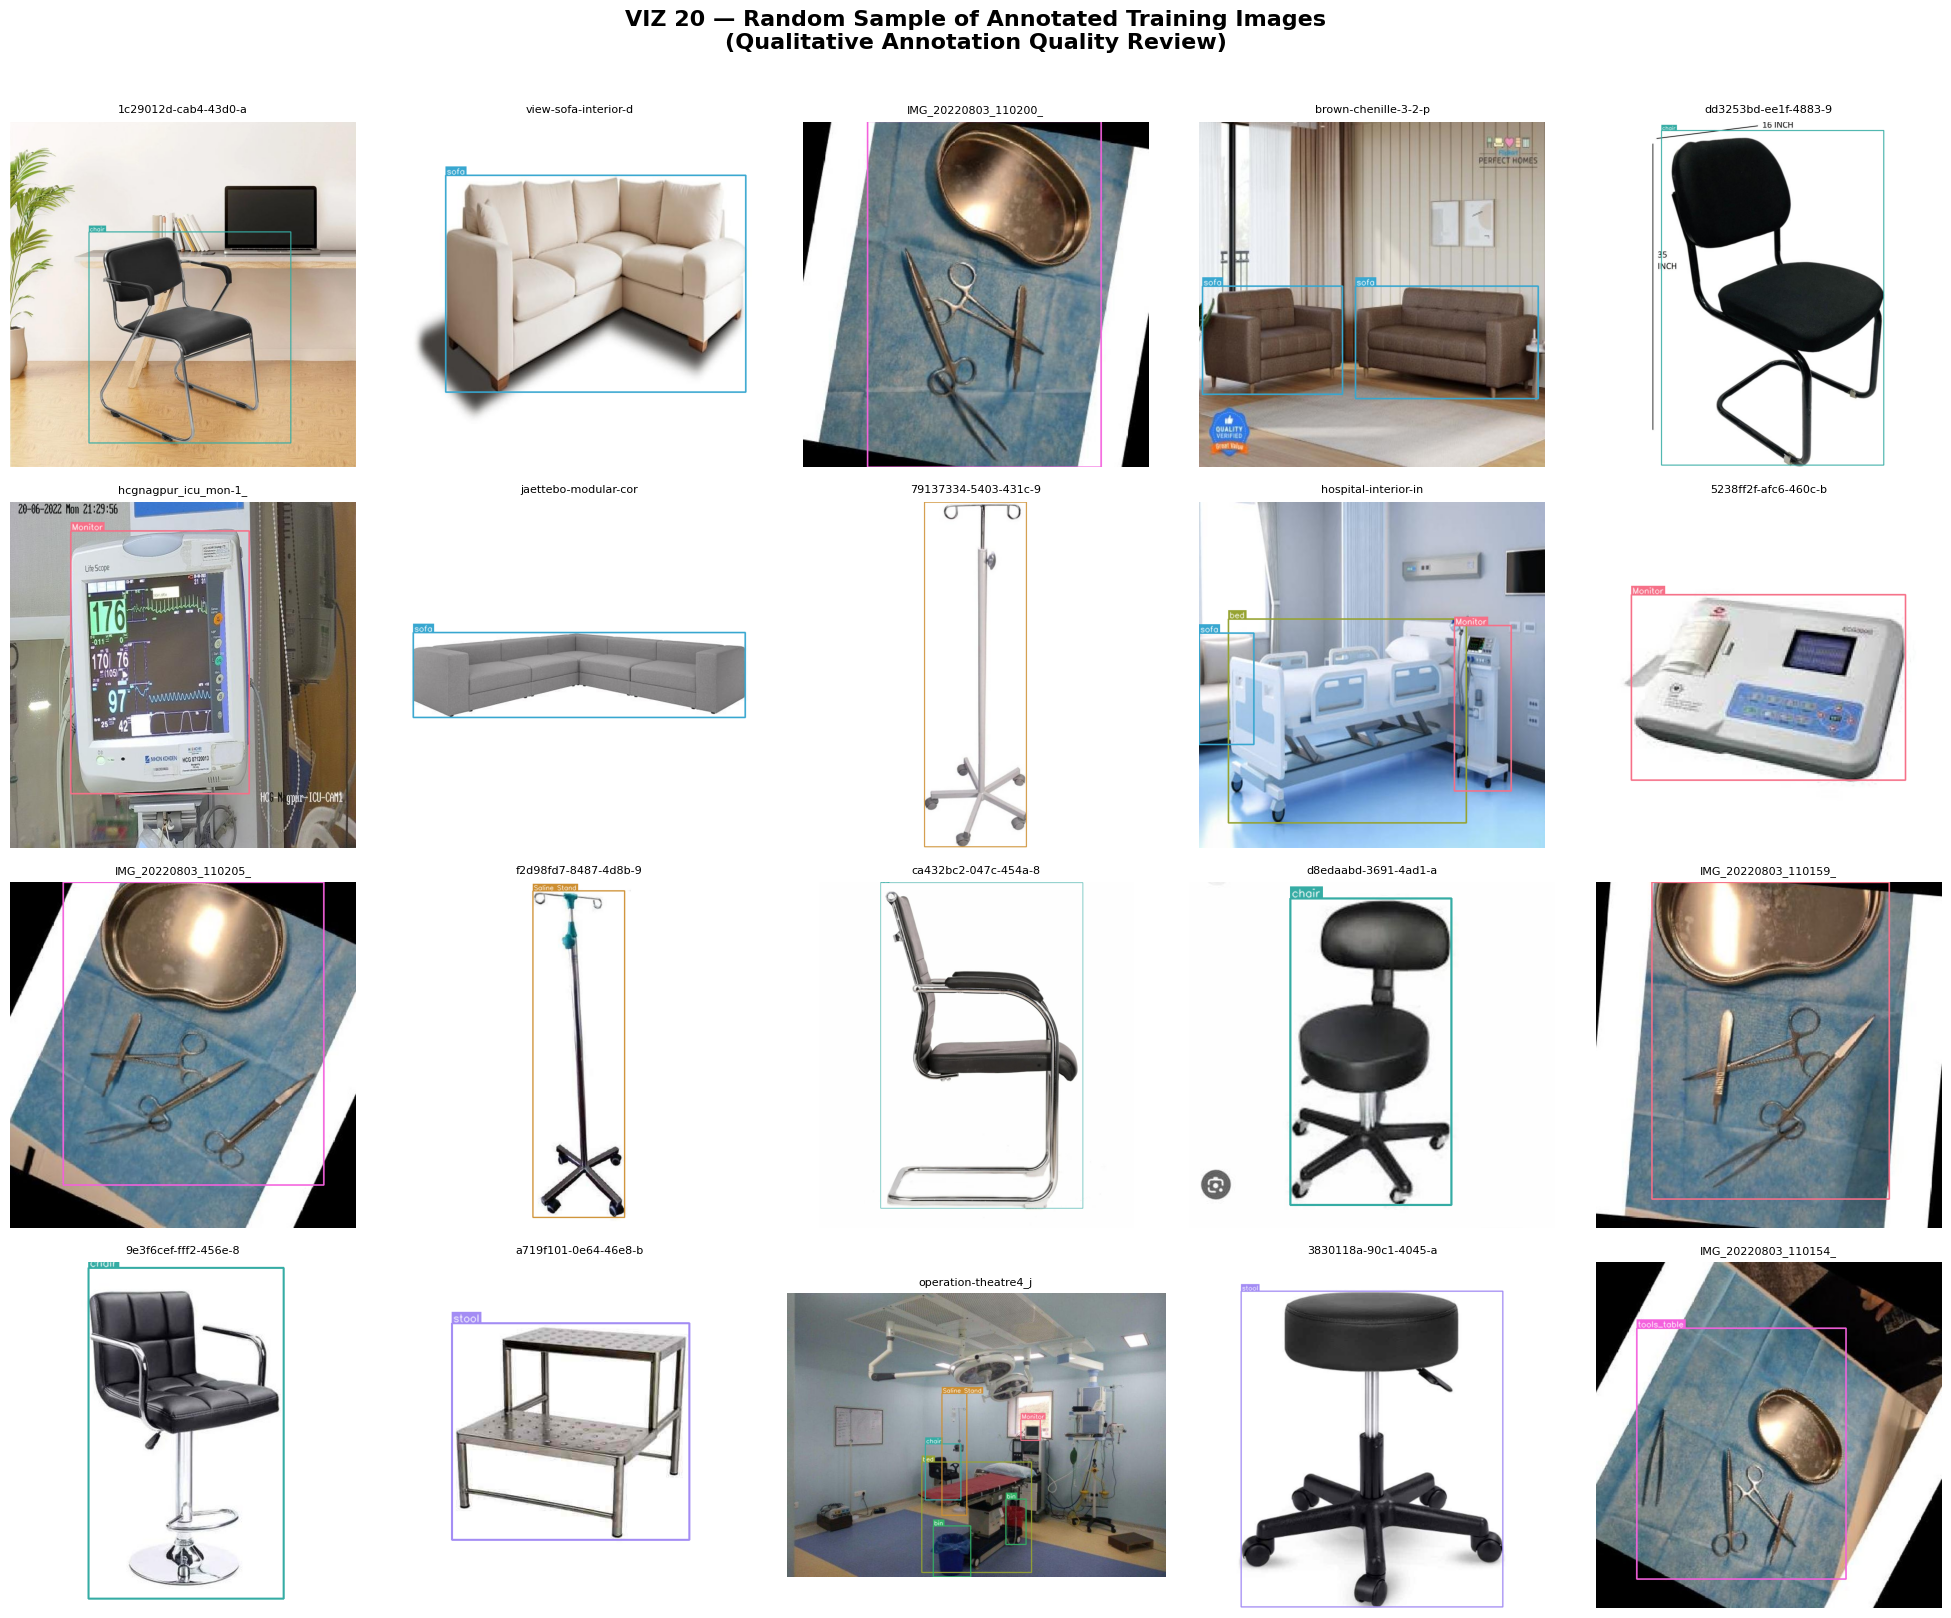

In [24]:
# ─── VISUALISATION 20: Sample Image Grid with Annotations ────────────────────
# WHY: Numbers and charts can only tell you so much. Seeing actual annotated images
# is essential to qualitatively assess annotation quality:
# - Are bounding boxes tight or loose?
# - Are truncated objects (at frame edges) labelled correctly?
# - Are any boxes mislabelled? (e.g. a chair labelled as stool)
# - What does a typical hospital scene in this dataset look like?
# This grid is the final slide of your EDA and the most visually impactful.

def draw_annotated_image(img_path, label_path, class_names, class_colors):
    """Loads an image and draws its annotations as coloured bounding boxes."""
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if label_path.exists():
        with open(label_path) as f:
            lines = f.read().strip().split('\n')
        for line in lines:
            if not line.strip(): continue
            parts = line.strip().split()
            if len(parts) != 5: continue
            cls_id, xc, yc, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            cls_name = class_names[cls_id] if cls_id < len(class_names) else f'cls_{cls_id}'
            color = tuple(int(c*255) for c in class_colors[cls_name][:3])
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            # Draw label background and text
            (tw, th), _ = cv2.getTextSize(cls_name, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img, (x1, y1-th-4), (x1+tw+4, y1), color, -1)
            cv2.putText(img, cls_name, (x1+2, y1-2), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255,255,255), 1, cv2.LINE_AA)
    return img

# Sample images from train split
train_img_dir = DATASET_ROOT / 'train' / 'images'
train_lbl_dir = DATASET_ROOT / 'train' / 'labels'
train_imgs = list(train_img_dir.glob('*.jpg')) + list(train_img_dir.glob('*.png'))
sample_imgs = random.sample(train_imgs, min(20, len(train_imgs)))

n_cols = 5
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
axes = axes.flatten()

for i, img_path in enumerate(sample_imgs[:n_rows*n_cols]):
    lbl_path = train_lbl_dir / (img_path.stem + '.txt')
    annotated = draw_annotated_image(img_path, lbl_path, CLASS_NAMES, CLASS_COLORS)
    if annotated is not None:
        axes[i].imshow(annotated)
    axes[i].axis('off')
    axes[i].set_title(img_path.stem[:20], fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('VIZ 20 — Random Sample of Annotated Training Images\n'
             '(Qualitative Annotation Quality Review)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz20_sample_annotated_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📋 SECTION 11 — EDA Summary & Recommendations

This section generates a structured summary report from all the analysis above.
Use this output directly in your presentation and project report.

In [26]:
# ─── AUTO-GENERATED EDA SUMMARY REPORT ───────────────────────────────────────

print('=' * 60)
print('   HOSPITAL DATASET EDA — SUMMARY REPORT')
print('   Vision-Based Wheelchair Navigation Project')
print('=' * 60)

print('\n📊 DATASET STATISTICS')
print(f'  Total images:            {df_all["image"].nunique()}')
print(f'  Total annotations:       {len(df_ann)}')
print(f'  Number of classes:       {NUM_CLASSES}')
print(f'  Avg annotations/image:   {len(df_ann)/df_all["image"].nunique():.2f}')
print(f'  Empty images (0 labels): {df_all[df_all["class_id"].isna()]["image"].nunique()}')

print('\n📌 CLASS DISTRIBUTION')
class_dist = df_ann['class_name'].value_counts()
for cls, count in class_dist.items():
    bar = '█' * (count // 20)
    status = '✅' if count >= 300 else ('⚠️ ' if count >= 100 else '🔴')
    print(f'  {status} {cls:<18} {count:>5}  {bar}')

print('\n⚠️  IMBALANCE ANALYSIS')
ratio = class_dist.max() / class_dist.min()
print(f'  Imbalance ratio:  {ratio:.1f}:1 (ideal < 5:1)')
print(f'  Most common:      {class_dist.idxmax()} ({class_dist.max()})')
print(f'  Least common:     {class_dist.idxmin()} ({class_dist.min()})')
underrepresented = class_dist[class_dist < 100]
print(f'  Classes < 100 annotations: {list(underrepresented.index)}')

print('\n🚨 MISSING NAVIGATION CLASSES')
missing = ['person/staff', 'door', 'wheelchair', 'trolley', 'corridor_sign']
for cls in missing:
    print(f'  ❌ {cls}')

print('\n🛠️  RECOMMENDED ACTIONS')
print('  1. Apply weighted loss (focal loss) during training to address class imbalance')
print('  2. Aggressively augment bin class images (flip, rotate, mosaic, colour jitter)')
print('  3. Source supplementary datasets for missing person/door/wheelchair classes')
print('  4. Normalise class names (Monitor→monitor, Saline Stand→saline_stand)')
print('  5. Remove or relabel any empty/mislabelled images found in qualitative review')
print('  6. Plan semi-supervised pseudo-labelling for person class using COCO weights')
print('  7. Validate annotation consistency with train/val/test class distribution check')

print('\n✅ SUITABILITY FOR YOLOV8 TRAINING')
print('  Base model:    YOLOv8n or YOLOv8s (small dataset, avoid overfitting)')
print('  Pretrained:    COCO weights (transfer learning — person class included)')
print('  Input size:    640×640 (verify matches dataset resolution from VIZ 14)')
print('  Epochs:        Start with 100, monitor val/mAP for early stopping')
print('  Augmentation:  Mosaic, horizontal flip, HSV colour shift, random scale')
print('  Class weights: Apply inverse frequency weighting to handle imbalance')

print('\n' + '=' * 60)

   HOSPITAL DATASET EDA — SUMMARY REPORT
   Vision-Based Wheelchair Navigation Project

📊 DATASET STATISTICS
  Total images:            1457
  Total annotations:       2411
  Number of classes:       8
  Avg annotations/image:   1.65
  Empty images (0 labels): 0

📌 CLASS DISTRIBUTION
  ✅ Monitor              594  █████████████████████████████
  ✅ bed                  511  █████████████████████████
  ✅ sofa                 356  █████████████████
  ⚠️  tools_table          255  ████████████
  ⚠️  stool                242  ████████████
  ⚠️  Saline Stand         218  ██████████
  ⚠️  chair                204  ██████████
  🔴 bin                   31  █

⚠️  IMBALANCE ANALYSIS
  Imbalance ratio:  19.2:1 (ideal < 5:1)
  Most common:      Monitor (594)
  Least common:     bin (31)
  Classes < 100 annotations: ['bin']

🚨 MISSING NAVIGATION CLASSES
  ❌ person/staff
  ❌ door
  ❌ wheelchair
  ❌ trolley
  ❌ corridor_sign

🛠️  RECOMMENDED ACTIONS
  1. Apply weighted loss (focal loss) during trainin

---
## 🎯 Class Merging & Name Normalisation Utility

**Run this AFTER EDA if you decide to merge or rename classes.**
It remaps class indices in all label files and rewrites data.yaml.

In [ ]:
# ─── CLASS MERGING UTILITY ────────────────────────────────────────────────────
# HOW TO USE:
# 1. Define CLASS_MERGE_MAP: old_class_name → new_class_name
# 2. Run the cell — it will rewrite all .txt label files in place
# 3. A new data.yaml will be written with the updated class list
# ⚠️  ALWAYS keep a backup of your original dataset before running this!

CLASS_MERGE_MAP = {
    # Standardise capitalisation and naming
    'Monitor':      'monitor',
    'Saline Stand': 'saline_stand',
    'bed':          'bed',
    'bin':          'bin',
    'chair':        'chair',
    'sofa':         'sofa',
    'stool':        'stool',
    'tools_table':  'tools_table',
    # Example merges (uncomment if you want to merge classes):
    # 'sofa':       'chair',   # Merge sofa into chair
    # 'stool':      'chair',   # Merge stool into chair
}

def remap_labels(dataset_root, merge_map):
    """
    Remaps class IDs in all YOLOv8 .txt label files.
    Updates data.yaml with new class list.
    """
    # Build old and new class lists
    old_classes = list(merge_map.keys())
    new_classes = sorted(set(merge_map.values()))  # deduplicated new class list
    old_to_new_id = {old_classes.index(old): new_classes.index(new)
                     for old, new in merge_map.items()
                     if old in old_classes}

    print(f'Old classes ({len(old_classes)}): {old_classes}')
    print(f'New classes ({len(new_classes)}): {new_classes}')
    print(f'ID mapping: {old_to_new_id}')

    # Remap all label files
    total_remapped = 0
    for split in ['train', 'valid', 'test']:
        label_dir = Path(dataset_root) / split / 'labels'
        if not label_dir.exists(): continue
        for label_path in label_dir.glob('*.txt'):
            with open(label_path, 'r') as f:
                lines = f.read().strip().split('\n')
            new_lines = []
            for line in lines:
                if not line.strip(): continue
                parts = line.strip().split()
                if len(parts) != 5: continue
                old_id = int(parts[0])
                new_id = old_to_new_id.get(old_id, old_id)
                new_lines.append(f'{new_id} {" ".join(parts[1:])}')
            with open(label_path, 'w') as f:
                f.write('\n'.join(new_lines))
            total_remapped += 1

    # Write new data.yaml
    new_yaml = {
        'train': '../train/images',
        'val': '../valid/images',
        'test': '../test/images',
        'nc': len(new_classes),
        'names': new_classes
    }
    with open(Path(dataset_root) / 'data_remapped.yaml', 'w') as f:
        yaml.dump(new_yaml, f, default_flow_style=False)

    print(f'\n✅ Remapped {total_remapped} label files')
    print(f'✅ Written new data_remapped.yaml with {len(new_classes)} classes')
    return new_classes

# ─── UNCOMMENT TO RUN (make a backup first!) ──────────────────────────────────
# new_class_list = remap_labels(DATASET_ROOT, CLASS_MERGE_MAP)
print('Class merging utility ready. Uncomment the last line to execute.')

---
## ✅ End of EDA Notebook

### Files Generated
All visualisations are saved as high-resolution PNG files:
- `viz01_split_overview.png` — Dataset split sizes
- `viz02_class_distribution.png` — Class imbalance bar chart
- `viz03_class_pie.png` — Class proportion pie chart
- `viz04_split_class_dist.png` — Class consistency across splits
- `viz05_annotations_per_image.png` — Scene complexity
- `viz07_bbox_width_hist.png` — Width distribution histogram
- `viz08_bbox_height_hist.png` — Height distribution histogram
- `viz09_aspect_ratio_hist.png` — Aspect ratio histogram
- `viz10_area_by_class_norm.png` — Normalised area by class
- `viz10b_area_by_class_pixels.png` — Pixel area by class
- `viz11_bbox_centre_hist2d.png` — Bounding box centre heatmap
- `viz12_x_center_dist.png` — x_center distribution
- `viz13_y_center_dist.png` — y_center distribution
- `viz14_navigable_space.png` — Navigation readiness per image
- `viz14_resolution.png` — Image resolution distribution
- `viz15_16_brightness_contrast.png` — Image quality metrics
- `viz17_rgb_channels.png` — Colour channel analysis
- `viz18_cooccurrence.png` — Class co-occurrence matrix
- `viz19_gap_analysis.png` — Navigation gap analysis
- `viz20_sample_annotated_images.png` — Qualitative sample review

### Next Steps
1. Review VIZ 20 manually — flag any mislabelled images
2. Run class merging utility if needed
3. Use gap analysis (VIZ 19) to source additional classes
4. Proceed to YOLOv8 fine-tuning with augmentation strategy
5. Integrate COCO person class via dual-head inference or dataset merging